In [69]:
!pip install datasets sentencepiece sacrebleu rouge-score torch

In [70]:
from datasets import load_dataset

ds = load_dataset("uqa/UQA")
print(ds)

ex = ds["train"][0]

print(ex.keys())
print(ex["question"])
print(ex["answer"])



DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 124745
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 16824
    })
})
dict_keys(['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'])
بیونس نے کب مقبولیت حاصل کرنا شروع کی؟
1990 کی دہائی کے آخر میں


In [71]:
n_total = len(ds["train"])
n_ans = sum(
    (not ex["is_impossible"]) and len(ex["answer"]) > 0
    for ex in ds["train"]
)
print(f"train rows: {n_total}, answerable: {n_ans}")


train rows: 124745, answerable: 83018


In [72]:
import csv

ANS_OPEN, ANS_CLOSE = "<ans>", "</ans>"

# Urdu full stop U+06D4, Urdu question mark U+061F, exclamation mark
SENT_DELIMS = "\u06D4\u061F!"


def split_sentences(text):
    """Yield (start, end, sentence) with offsets into `text`."""
    start = 0

    for i, ch in enumerate(text):
        if ch in SENT_DELIMS:
            yield start, i + 1, text[start:i + 1]
            start = i + 1

    if start < len(text):
        yield start, len(text), text[start:]


def make_pair(example, max_src=60, max_tgt=25):
    """Return (source, target) or None if the row is unusable."""

    # UQA uses answer and answer_start directly
    a_start = example["answer_start"]
    a_text = example["answer"]

    # Unanswerable -> skip
    if example["is_impossible"] or not a_text:
        return None

    a_end = a_start + len(a_text)

    context = example["context"]

    for s, e, sent in split_sentences(context):

        if s <= a_start < e:

            rel = a_start - s  # offset inside the sentence

            if sent[rel:rel + len(a_text)] != a_text:
                return None  # offset mismatch -> skip

            src = (
                sent[:rel]
                + " " + ANS_OPEN + " " + a_text + " "
                + ANS_CLOSE + " "
                + sent[rel + len(a_text):]
            ).strip()

            src = " ".join(src.split())  # normalise whitespace

            tgt = " ".join(example["question"].split())

            if len(src.split()) > max_src or len(tgt.split()) > max_tgt:
                return None

            return src, tgt

    return None


def build_split(split, out_path):
    pairs = [p for p in map(make_pair, split) if p is not None]

    with open(
        out_path,
        "w",
        encoding="utf-8",
        newline=""
    ) as f:

        w = csv.writer(
            f,
            delimiter="\t",
            quoting=csv.QUOTE_NONE,
            escapechar="\\"
        )

        w.writerows(pairs)

    print(f"{out_path}: {len(pairs)} pairs")

    return pairs


train_pairs = build_split(
    ds["train"],
    "train.tsv"
)

valid_pairs = build_split(
    ds["validation"],
    "valid.tsv"
)

train.tsv: 75067 pairs
valid.tsv: 10018 pairs


In [73]:
with open("sp_corpus.txt", "w", encoding="utf-8") as f:
    for src, tgt in train_pairs:
        f.write(src + "\n")
        f.write(tgt + "\n")

In [74]:
import sentencepiece as spm

spm.SentencePieceTrainer.train(
    input="sp_corpus.txt",
    model_prefix="ur_sp",
    vocab_size=8000,
    model_type="unigram",
    character_coverage=1.0,
    user_defined_symbols=["<ans>", "</ans>"],
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
)

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: sp_corpus.txt
  input_format: 
  model_prefix: ur_sp
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 1
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_symbols: <ans>
  user_defined_symbols: </ans>
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 1
  bos_id: 2
  eos_id: 3
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_

In [75]:
sp = spm.SentencePieceProcessor(model_file="ur_sp.model")
PAD, UNK, BOS, EOS = 0, 1, 2, 3

src, tgt = train_pairs[0]
print(sp.encode(src, out_type=str))   # pieces, e.g. ['▁دریائے', '▁سندھ', ...]
print(sp.encode(tgt))                 # ids
print(sp.decode(sp.encode(tgt)) == tgt)  # round-trip check — should be True

['▁ہی', 'وسٹن', '▁،', '▁ٹیکساس', '▁میں', '▁پیدا', '▁ہوئی', '▁اور', '▁اس', '▁کی', '▁پر', 'ورش', '▁ہوئی', '▁،', '▁اس', '▁نے', '▁', 'بچپن', '▁میں', '▁مختلف', '▁گانے', '▁اور', '▁رقص', '▁کے', '▁مقابل', 'وں', '▁میں', '▁پرفارم', '▁کیا', '▁،', '▁اور', '▁', '<ans>', '▁1990', '▁کی', '▁دہائی', '▁کے', '▁آخر', '▁میں', '▁', '</ans>', '▁R', '&', 'B', '▁گرل', '▁گروپ', '▁ڈسٹ', 'نی', '▁چائلڈ', '▁کے', '▁لیڈ', '▁گلوکار', '▁کی', '▁حیثیت', '▁سے', '▁شہرت', '▁حاصل', '▁کی۔']
[2664, 20, 96, 2744, 114, 156, 113, 9, 11]
True


# five tokenised examples

In [76]:
import random

random.seed(7)  # pick any seed; just be consistent
sample_examples = random.sample(train_pairs, 5)

for i, (src, tgt) in enumerate(sample_examples, 1):
    src_pieces = sp.encode(src, out_type=str)
    tgt_pieces = sp.encode(tgt, out_type=str)
    print(f"--- Example {i} ---")
    print(f"Source text:   {src}")
    print(f"Source pieces: {src_pieces}")
    print(f"Target text:   {tgt}")
    print(f"Target pieces: {tgt_pieces}")
    print()

--- Example 1 ---
Source text:   10 علاقائی کارروائیوں میں اس آپریشن کے نتیجے میں تقریبا 60 60،000 <ans> پولینڈ کے اشرافیہ ، اساتذہ ، سماجی کارکن ، پادری ، جج اور سیاسی کارکن </ans> مارے گئے۔
Source pieces: ['▁10', '▁علاقائی', '▁کارروائی', 'وں', '▁میں', '▁اس', '▁آپریشن', '▁کے', '▁نتیج', 'ے', '▁میں', '▁تقریبا', '▁60', '▁60،000', '▁', '<ans>', '▁پولینڈ', '▁کے', '▁اشرافیہ', '▁،', '▁اس', 'ات', 'ذہ', '▁،', '▁سماجی', '▁کارکن', '▁،', '▁پادری', '▁،', '▁جج', '▁اور', '▁سیاسی', '▁کارکن', '▁', '</ans>', '▁مارے', '▁گئے۔']
Target text:   <unk>intelligentia<unk> کون تھے؟<unk>
Target pieces: ['▁', '<', 'un', 'k', '>', 'in', 't', 'ell', 'i', 'g', 'ent', 'ia', '<', 'un', 'k', '>', '▁کون', '▁تھے', '؟', '<', 'un', 'k', '>']

--- Example 2 ---
Source text:   ریورس ہجرت، جہاں نوجوان پرندوں کی جینیاتی پروگرامنگ مناسب طریقے سے کام کرنے میں ناکام رہتی ہے، اس کے نتیجے میں نایاب پرندے <ans> ہزاروں کلومیٹر </ans> کی حد سے باہر گھومنے پھرنے کے طور پر ظاہر ہوسکتے ہیں۔
Source pieces: ['▁ریورس', '▁ہجرت', '،', '▁جہاں'

In [77]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden_dim=512, n_layers=2, dropout=0.3, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=n_layers,
                             batch_first=True, bidirectional=True,
                             dropout=dropout if n_layers > 1 else 0.0)
        self.bridge_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.bridge_c = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_outputs, (hidden, cell) = self.lstm(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)

        n_layers = hidden.size(0) // 2
        bridged_h, bridged_c = [], []
        for layer in range(n_layers):
            h_cat = torch.cat([hidden[2*layer], hidden[2*layer+1]], dim=-1)
            c_cat = torch.cat([cell[2*layer], cell[2*layer+1]], dim=-1)
            bridged_h.append(torch.tanh(self.bridge_h(h_cat)))
            bridged_c.append(torch.tanh(self.bridge_c(c_cat)))
        dec_hidden = torch.stack(bridged_h, dim=0)
        dec_cell = torch.stack(bridged_c, dim=0)
        return outputs, (dec_hidden, dec_cell)




In [78]:
class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attn_dim=256):
        super().__init__()
        self.W_enc = nn.Linear(encoder_dim, attn_dim, bias=False)
        self.W_dec = nn.Linear(decoder_dim, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_mask):
        dec_proj = self.W_dec(decoder_hidden).unsqueeze(1)
        enc_proj = self.W_enc(encoder_outputs)
        scores = self.v(torch.tanh(dec_proj + enc_proj)).squeeze(-1)
        scores = scores.masked_fill(src_mask == 0, float("-inf"))
        weights = F.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, weights




In [79]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden_dim=512, encoder_dim=1024,
                 n_layers=2, dropout=0.3, pad_id=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_id)
        self.attention = BahdanauAttention(encoder_dim, hidden_dim)
        self.lstm = nn.LSTM(emb_dim + encoder_dim, hidden_dim, num_layers=n_layers,
                             batch_first=True, dropout=dropout if n_layers > 1 else 0.0)
        self.out = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward_step(self, input_token, hidden_cell, encoder_outputs, src_mask):
        hidden, cell = hidden_cell
        embedded = self.dropout(self.embedding(input_token))
        top_hidden = hidden[-1]
        context, attn_weights = self.attention(top_hidden, encoder_outputs, src_mask)
        context = context.unsqueeze(1)
        lstm_input = torch.cat([embedded, context], dim=-1)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        logits = self.out(output.squeeze(1))
        return logits, (hidden, cell), attn_weights




In [80]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, pad_id=0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_id = pad_id

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=1.0):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.out.out_features
        device = src.device

        encoder_outputs, hidden_cell = self.encoder(src, src_lengths)
        src_mask = (src != self.pad_id).long()

        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=device)
        input_token = tgt[:, 0].unsqueeze(1)  # <s>

        for t in range(1, tgt_len):
            logits, hidden_cell, _ = self.decoder.forward_step(input_token, hidden_cell, encoder_outputs, src_mask)
            outputs[:, t] = logits
            use_tf = torch.rand(1).item() < teacher_forcing_ratio
            input_token = tgt[:, t].unsqueeze(1) if use_tf else logits.argmax(-1, keepdim=True)

        return outputs

In [81]:
import torch
from torch.utils.data import Dataset, DataLoader

class QGDataset(Dataset):
    def __init__(self, tsv_path, sp, max_src=60, max_tgt=25):
        self.pairs = []
        with open(tsv_path, encoding="utf-8") as f:
            for line in f:
                src, tgt = line.rstrip("\n").split("\t")
                self.pairs.append((src, tgt))
        self.sp = sp
        self.max_src, self.max_tgt = max_src, max_tgt

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = [self.sp.bos_id()] + self.sp.encode(src) + [self.sp.eos_id()]
        tgt_ids = [self.sp.bos_id()] + self.sp.encode(tgt) + [self.sp.eos_id()]
        return torch.tensor(src_ids), torch.tensor(tgt_ids)



In [82]:
def collate_fn(batch, pad_id=0):
    srcs, tgts = zip(*batch)
    src_lengths = torch.tensor([len(s) for s in srcs])
    src_padded = nn.utils.rnn.pad_sequence(srcs, batch_first=True, padding_value=pad_id)
    tgt_padded = nn.utils.rnn.pad_sequence(tgts, batch_first=True, padding_value=pad_id)
    return src_padded, src_lengths, tgt_padded



In [83]:
# --- training loop ---
def train_epoch(model, dataloader, optimizer, criterion, device, teacher_forcing_ratio=1.0):
    model.train()
    total_loss = 0
    for src, src_lengths, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        outputs = model(src, src_lengths, tgt, teacher_forcing_ratio)
        vocab_size = outputs.size(-1)
        loss = criterion(outputs[:, 1:].reshape(-1, vocab_size), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stabilizes RNN training
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)



In [90]:
@torch.no_grad()
def evaluate_epoch(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    for src, src_lengths, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        outputs = model(src, src_lengths, tgt, teacher_forcing_ratio=1.0)  
        vocab_size = outputs.size(-1)
        loss = criterion(outputs[:, 1:].reshape(-1, vocab_size), tgt[:, 1:].reshape(-1))
        total_loss += loss.item()
    return total_loss / len(dataloader)

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
VOCAB_SIZE = sp.get_piece_size()

encoder = Encoder(vocab_size=VOCAB_SIZE, emb_dim=256, hidden_dim=512, n_layers=2, dropout=0.3, pad_id=PAD).to(device)
decoder = Decoder(vocab_size=VOCAB_SIZE, emb_dim=256, hidden_dim=512, encoder_dim=1024, n_layers=2, dropout=0.3, pad_id=PAD).to(device)
model = Seq2Seq(encoder, decoder, pad_id=PAD).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

Trainable parameters: 24,872,000


In [92]:
train_dataset = QGDataset("train.tsv", sp)
valid_dataset = QGDataset("valid.tsv", sp)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

In [93]:
import random, time

random.seed(42)
train_subset = random.sample(train_pairs, 10000)

with open("train_subset.tsv", "w", encoding="utf-8") as f:
    for src, tgt in train_subset:
        f.write(f"{src}\t{tgt}\n")

subset_dataset = QGDataset("train_subset.tsv", sp)
subset_loader = DataLoader(subset_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# fresh, throwaway model just for this check
debug_encoder = Encoder(vocab_size=VOCAB_SIZE, emb_dim=256, hidden_dim=512, n_layers=2, dropout=0.3, pad_id=PAD).to(device)
debug_decoder = Decoder(vocab_size=VOCAB_SIZE, emb_dim=256, hidden_dim=512, encoder_dim=1024, n_layers=2, dropout=0.3, pad_id=PAD).to(device)
debug_model = Seq2Seq(debug_encoder, debug_decoder, pad_id=PAD).to(device)
debug_optimizer = torch.optim.Adam(debug_model.parameters(), lr=1e-3)

for epoch in range(1, 6):
    loss = train_epoch(debug_model, subset_loader, debug_optimizer, criterion, device)
    print(f"[subset] epoch {epoch}: loss = {loss:.4f}")

[subset] epoch 1: loss = 6.1468
[subset] epoch 2: loss = 5.8505
[subset] epoch 3: loss = 5.7533
[subset] epoch 4: loss = 5.6243
[subset] epoch 5: loss = 5.4765


In [94]:
debug_model.eval()

with torch.no_grad():

    src, src_lengths, tgt = next(iter(subset_loader))

    src = src.to(device)
    src_lengths = src_lengths.to(device)

    # Encode
    encoder_outputs, hidden_cell = debug_model.encoder(
        src[:1],
        src_lengths[:1]
    )

    # Build mask matching encoder_outputs sequence length
    B, S, _ = encoder_outputs.shape

    src_mask = (
        torch.arange(S, device=device).unsqueeze(0)
        < src_lengths[:1].unsqueeze(1)
    ).long()

    print("src:", src[:1].shape)
    print("src_lengths:", src_lengths[:1])
    print("encoder_outputs:", encoder_outputs.shape)
    print("src_mask:", src_mask.shape)

    input_token = torch.tensor([[BOS]], device=device)

    generated = []

    for _ in range(20):

        logits, hidden_cell, _ = debug_model.decoder.forward_step(
            input_token,
            hidden_cell,
            encoder_outputs,
            src_mask
        )

        next_id = logits.argmax(-1, keepdim=True)

        generated.append(next_id.item())

        if next_id.item() == EOS:
            break

        input_token = next_id

    print(sp.decode(generated))

src: torch.Size([1, 85])
src_lengths: tensor([30], device='cuda:0')
encoder_outputs: torch.Size([1, 30, 1024])
src_mask: torch.Size([1, 30])
کس سال کے کے کے کے کے کے کے کے؟


In [95]:
# fresh model for the real run
encoder = Encoder(vocab_size=VOCAB_SIZE, emb_dim=256, hidden_dim=512, n_layers=2, dropout=0.3, pad_id=PAD).to(device)
decoder = Decoder(vocab_size=VOCAB_SIZE, emb_dim=256, hidden_dim=512, encoder_dim=1024, n_layers=2, dropout=0.3, pad_id=PAD).to(device)
model = Seq2Seq(encoder, decoder, pad_id=PAD).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}")

import os, json
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results", exist_ok=True)

N_EPOCHS = 15
best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

start_time = time.time()
for epoch in range(1, N_EPOCHS + 1):
    epoch_start = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion, device,teacher_forcing_ratio=0.65)
    val_loss = evaluate_epoch(model, valid_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    epoch_time = time.time() - epoch_start
    print(f"Epoch {epoch}/{N_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | time={epoch_time:.1f}s")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "checkpoints/best_model.pt")
        print(f"  -> new best checkpoint saved (val_loss={val_loss:.4f})")

    # save history every epoch so a disconnect doesn't lose it
    with open("results/history.json", "w") as f:
        json.dump(history, f)

total_time = time.time() - start_time
print(f"Total training time: {total_time/60:.1f} minutes")

Trainable parameters: 24,872,000
Epoch 1/15 | train_loss=5.6808 | val_loss=5.2854 | time=360.1s
  -> new best checkpoint saved (val_loss=5.2854)
Epoch 2/15 | train_loss=4.9749 | val_loss=4.8680 | time=361.8s
  -> new best checkpoint saved (val_loss=4.8680)
Epoch 3/15 | train_loss=4.6817 | val_loss=4.6899 | time=362.5s
  -> new best checkpoint saved (val_loss=4.6899)
Epoch 4/15 | train_loss=4.4546 | val_loss=4.5808 | time=361.8s
  -> new best checkpoint saved (val_loss=4.5808)
Epoch 5/15 | train_loss=4.3232 | val_loss=4.4547 | time=361.2s
  -> new best checkpoint saved (val_loss=4.4547)
Epoch 6/15 | train_loss=4.1662 | val_loss=4.4021 | time=362.6s
  -> new best checkpoint saved (val_loss=4.4021)
Epoch 7/15 | train_loss=4.0450 | val_loss=4.3325 | time=362.4s
  -> new best checkpoint saved (val_loss=4.3325)
Epoch 8/15 | train_loss=3.9356 | val_loss=4.3180 | time=362.9s
  -> new best checkpoint saved (val_loss=4.3180)
Epoch 9/15 | train_loss=3.8598 | val_loss=4.2891 | time=362.6s
  -> new

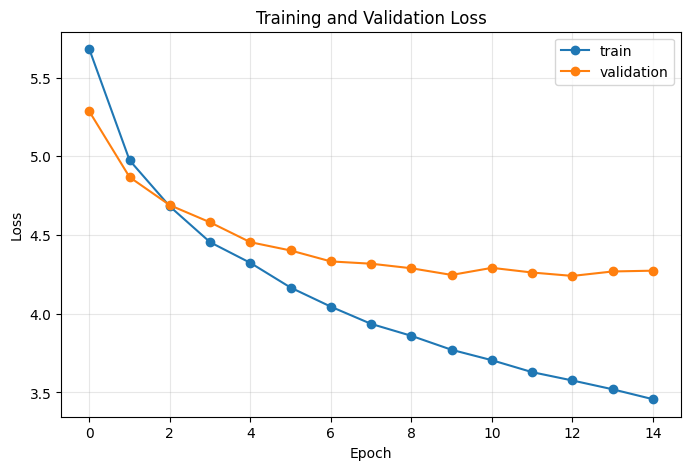

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history["train_loss"], label="train", marker="o")
plt.plot(history["val_loss"], label="validation", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("results/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [97]:
@torch.no_grad()
def decode_greedy(model, sp, src_text, device, max_len=30):
    model.eval()
    src_ids = [sp.bos_id()] + sp.encode(src_text) + [sp.eos_id()]
    src = torch.tensor([src_ids], device=device)
    src_lengths = torch.tensor([len(src_ids)])

    encoder_outputs, hidden_cell = model.encoder(src, src_lengths)
    src_mask = (src != model.pad_id).long()

    input_token = torch.tensor([[sp.bos_id()]], device=device)
    generated_ids = []

    for _ in range(max_len):
        logits, hidden_cell, _ = model.decoder.forward_step(input_token, hidden_cell, encoder_outputs, src_mask)
        next_id = logits.argmax(-1, keepdim=True)
        token_id = next_id.item()
        if token_id == sp.eos_id():
            break
        generated_ids.append(token_id)
        input_token = next_id

    return sp.decode(generated_ids)

In [98]:
print(decode_greedy(model, sp, train_pairs[0][0], device))

کس دہائی میں Schwarzenegger نے پہلی بار کب پرفارم کیا؟


In [99]:
@torch.no_grad()
def decode_beam(model, sp, src_text, device, beam_width=3, max_len=30):
    model.eval()
    src_ids = [sp.bos_id()] + sp.encode(src_text) + [sp.eos_id()]
    src = torch.tensor([src_ids], device=device)
    src_lengths = torch.tensor([len(src_ids)])

    encoder_outputs, hidden_cell = model.encoder(src, src_lengths)
    src_mask = (src != model.pad_id).long()

    # each beam: (cumulative_log_prob, token_ids_so_far, hidden_cell, finished)
    beams = [(0.0, [], hidden_cell, False)]

    for _ in range(max_len):
        all_candidates = []
        for score, seq, hc, finished in beams:
            if finished:
                all_candidates.append((score, seq, hc, True))
                continue

            last_token = seq[-1] if seq else sp.bos_id()
            input_token = torch.tensor([[last_token]], device=device)
            logits, new_hc, _ = model.decoder.forward_step(input_token, hc, encoder_outputs, src_mask)
            log_probs = F.log_softmax(logits, dim=-1).squeeze(0)  # (vocab_size,)

            top_log_probs, top_ids = log_probs.topk(beam_width)
            for lp, tid in zip(top_log_probs.tolist(), top_ids.tolist()):
                new_seq = seq + [tid]
                new_finished = (tid == sp.eos_id())
                all_candidates.append((score + lp, new_seq, new_hc, new_finished))

        # keep top beam_width candidates by cumulative score
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        beams = all_candidates[:beam_width]

        if all(b[3] for b in beams):  # every beam hit EOS
            break

    best_score, best_seq, _, _ = beams[0]
    # strip trailing EOS if present
    if best_seq and best_seq[-1] == sp.eos_id():
        best_seq = best_seq[:-1]
    return sp.decode(best_seq)

In [100]:
print("Greedy:", decode_greedy(model, sp, train_pairs[5][0], device))
print("Beam:  ", decode_beam(model, sp, train_pairs[5][0], device, beam_width=5))

Greedy: اس کے ساتھ ساتھ، کون سا گلوکار نے  ⁇ "دیی ⁇ " گایا؟
Beam:   ڈسٹنی چائلڈ کے ساتھ ساتھ، بیونس نے کون سا گانا گایا؟


In [101]:
@torch.no_grad()
def decode_greedy_with_attention(model, sp, src_text, device, max_len=30):
    model.eval()
    src_ids = [sp.bos_id()] + sp.encode(src_text) + [sp.eos_id()]
    src = torch.tensor([src_ids], device=device)
    src_lengths = torch.tensor([len(src_ids)])

    encoder_outputs, hidden_cell = model.encoder(src, src_lengths)
    src_mask = (src != model.pad_id).long()

    input_token = torch.tensor([[sp.bos_id()]], device=device)
    generated_ids = []
    attention_matrix = []  # one row per generated token

    for _ in range(max_len):
        logits, hidden_cell, attn_weights = model.decoder.forward_step(input_token, hidden_cell, encoder_outputs, src_mask)
        attention_matrix.append(attn_weights.squeeze(0).cpu().numpy())  # (src_len,)

        next_id = logits.argmax(-1, keepdim=True)
        token_id = next_id.item()
        if token_id == sp.eos_id():
            break
        generated_ids.append(token_id)
        input_token = next_id

    src_pieces = sp.encode(src_text, out_type=str)
    src_pieces = ["<s>"] + src_pieces + ["</s>"]  # matches src_ids
    gen_pieces = [sp.id_to_piece(t) for t in generated_ids]

    return sp.decode(generated_ids), attention_matrix[:len(generated_ids)], src_pieces

In [103]:
import matplotlib.pyplot as plt
import numpy as np

def plot_attention_heatmap(src_pieces, gen_pieces, attention_matrix):
    attention_matrix = np.array(attention_matrix)

    plt.figure(figsize=(14, 6))

    plt.imshow(
        attention_matrix,
        aspect="auto",
        cmap="viridis"
    )

    plt.colorbar(label="Attention Weight")

    plt.xticks(
        range(len(src_pieces)),
        src_pieces,
        rotation=90
    )

    plt.yticks(
        range(len(gen_pieces)),
        gen_pieces
    )

    plt.xlabel("Source Tokens")
    plt.ylabel("Generated Question Tokens")
    plt.title("Bahdanau Attention Heatmap")

    plt.tight_layout()
    plt.show()

Generated: کون سے دو گروہوں نے اپنے کے ساتھ کے ساتھ کام کیا؟


/tmp/ipykernel_58/3294831221.py:32: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3294831221.py:32: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_58/3294831221.py:32: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/3294831221.py:32: UserWarning: Glyph 1748 (\N{ARABIC FULL STOP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtool

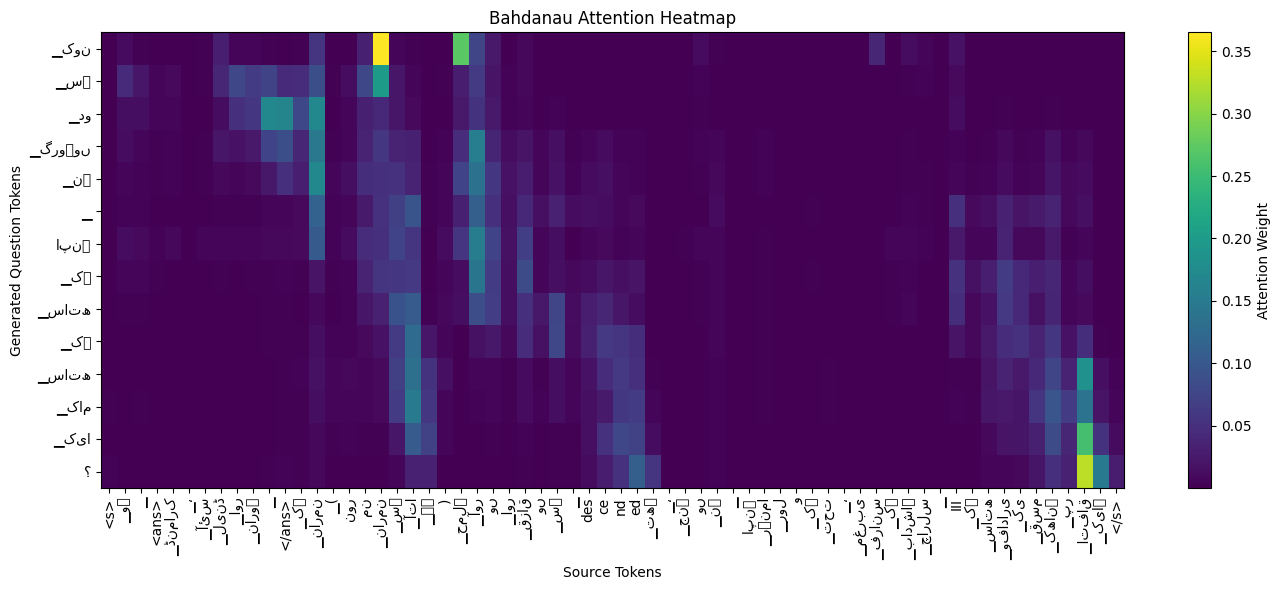

In [104]:
example_src = valid_pairs[3][0]  # pick any example, ideally one with a shortish source
generated_text, attention_matrix, src_pieces = decode_greedy_with_attention(model, sp, example_src, device)
gen_pieces = sp.encode(generated_text, out_type=str)

print("Generated:", generated_text)
plot_attention_heatmap(src_pieces, gen_pieces, attention_matrix)

In [113]:
from rouge_score.tokenizers import Tokenizer

class WhitespaceTokenizer(Tokenizer):
    def tokenize(self, text):
        return text.split()

In [114]:
import sacrebleu
from rouge_score import rouge_scorer

def run_evaluation(model, sp, pairs, device, beam_width=5, max_examples=None):
    if max_examples:
        pairs = pairs[:max_examples]

    refs, greedy_hyps, beam_hyps = [], [], []
    for src, tgt in pairs:
        refs.append(tgt)
        greedy_hyps.append(decode_greedy(model, sp, src, device))
        beam_hyps.append(decode_beam(model, sp, src, device, beam_width=beam_width))

    def score(hyps, refs):
        bleu = sacrebleu.corpus_bleu(hyps, [refs]).score
        scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False, tokenizer=WhitespaceTokenizer())
        rl = sum(scorer.score(r, h)["rougeL"].fmeasure for h, r in zip(hyps, refs)) / len(refs)
        unk_rate = sum(h.count("\u2047") for h in hyps) / max(1, sum(len(h.split()) for h in hyps))
        return {"BLEU-4": bleu, "ROUGE-L": rl, "unk_rate": unk_rate}

    return {
        "greedy": score(greedy_hyps, refs),
        "beam": score(beam_hyps, refs),
        "samples": list(zip([p[0] for p in pairs], refs, greedy_hyps, beam_hyps))
    }

In [115]:
import math
val_loss = evaluate_epoch(model, valid_loader, criterion, device)
perplexity = math.exp(val_loss)
print(f"Validation perplexity: {perplexity:.2f}")

Validation perplexity: 75.45


In [116]:
from datasets import load_dataset
wiki_ds = load_dataset("uqa/Wiki-UQA")
print(wiki_ds) 

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'is_impossible', 'answer', 'answer_start'],
        num_rows: 210
    })
})


In [117]:
wiki_pairs = [p for p in map(make_pair, wiki_ds["train"]) if p is not None]
print(f"Wiki-UQA usable pairs: {len(wiki_pairs)}")

wiki_results = run_evaluation(model, sp, wiki_pairs, device, max_examples=None)  
print("Wiki-UQA greedy:", wiki_results["greedy"])
print("Wiki-UQA beam:  ", wiki_results["beam"])

Wiki-UQA usable pairs: 177
Wiki-UQA greedy: {'BLEU-4': 1.1479026719607004, 'ROUGE-L': 0.17891557935860758, 'unk_rate': 0.027578599007170437}
Wiki-UQA beam:   {'BLEU-4': 2.146772566068068, 'ROUGE-L': 0.16862097276467228, 'unk_rate': 0.015782828282828284}


In [118]:
uqa_results = run_evaluation(model, sp, valid_pairs, device, max_examples=200)


In [121]:
uqa_results["greedy"]

{'BLEU-4': 3.016133666067634,
 'ROUGE-L': 0.19929919689887993,
 'unk_rate': 0.012605042016806723}

In [122]:
uqa_results["beam"]  

{'BLEU-4': 2.3858062486233877,
 'ROUGE-L': 0.18097972216429187,
 'unk_rate': 0.009659090909090909}

In [123]:
uqa_results["samples"][0]

('نارمن (Norman: Nourmands؛ French: Normands؛ Latin: Normanni) وہ لوگ تھے جنہوں نے 10 ویں اور 11 ویں صدیوں میں <ans> فرانس </ans> کے ایک خطے نارمنڈی کو اپنا نام دیا۔',
 'نارمنڈی کس ملک میں واقع ہے؟',
 'پندرہویں صدی کے آخر میں کس نے کے علاقے کو کیا کہا جاتا تھا؟',
 'پندرہویں صدی کے آخر میں کون سی سلطنت نے  کو کو کہا جاتا تھا؟')

In [124]:
import csv
with open("samples.csv", "w", encoding="utf-8", newline="") as f:
    w = csv.writer(f, delimiter=",")
    w.writerow(["source", "reference", "greedy", "beam"])
    for src, ref, g, b in uqa_results["samples"][:50]:
        w.writerow([src, ref, g, b])

In [125]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score

# File paths
rating_beam_1 = "/kaggle/input/datasets/qasimzubair/ratings/member1_beam_ratings.csv"
rating_beam_2 = "/kaggle/input/datasets/qasimzubair/ratings/member2_beam_ratings.csv"
rating_greedy_1 = "/kaggle/input/datasets/qasimzubair/ratings/member1_greedy_ratings.csv"
rating_greedy_2 = "/kaggle/input/datasets/qasimzubair/ratings/member2_greedy_ratings.csv"

m1_greedy = pd.read_csv(rating_greedy_1)
m2_greedy = pd.read_csv(rating_greedy_2)
m1_beam = pd.read_csv(rating_beam_1)
m2_beam = pd.read_csv(rating_beam_2)

# sanity check: same number of rated rows on both sides
assert len(m1_greedy) == len(m2_greedy), "Greedy files: row count mismatch!"
assert len(m1_beam) == len(m2_beam), "Beam files: row count mismatch!"

criteria = ["fluency", "relevance", "answerability"]

for decoding, m1, m2 in [("Greedy", m1_greedy, m2_greedy), ("Beam", m1_beam, m2_beam)]:
    for c in criteria:
        m1_yes = m1[c].mean() * 100
        m2_yes = m2[c].mean() * 100
        try:
            kappa = cohen_kappa_score(m1[c], m2[c])
            kappa_str = f"{kappa:.3f}"
        except Exception:
            kappa_str = "undefined (no variance in one rater's ratings)"
        print(f"  {c.capitalize():14s} | Member1={m1_yes:5.1f}% yes | Member2={m2_yes:5.1f}% yes | κ={kappa_str}")
    print()

  Fluency        | Member1= 10.0% yes | Member2=  0.0% yes | κ=0.000
  Relevance      | Member1= 14.0% yes | Member2=  4.0% yes | κ=0.408
  Answerability  | Member1=  0.0% yes | Member2=  0.0% yes | κ=nan

  Fluency        | Member1= 12.0% yes | Member2= 12.0% yes | κ=0.621
  Relevance      | Member1= 20.0% yes | Member2=  8.0% yes | κ=0.516
  Answerability  | Member1=  0.0% yes | Member2=  0.0% yes | κ=nan



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)
